# Notebook to fit mocks:

**Remark:** 
 * I work in my local branch of `desi-clustering`: `edmond-dev`
 * For now it turns with `desilike/dr2-dev`

In [1]:
import logging

import os
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

# remove warning on my mac -> deactivate on NERSC.
os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

plt.style.use('ec_style.mplstyle')   

# # disable jax warning:
# logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
# logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# # Remove warning from jax
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [2]:
def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()


def propose_fiducial():
    """ 
    """
    propose_fiducial = {}

    kmin = 3e-3

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}  #6e-3
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 
                                   'use_ell2': True, 'kmin': kmin, 'kmax': 0.08, 'kmin_ell2': kmin, 'kmax_ell2': 0.08}   
    
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = propose_fiducial['LRGxELG']
      
    return propose_fiducial


def load_data(data_dir, mocks_dir, tracers_to_read, fiducial=propose_fiducial(), add_ic=True, nmocks_mean=100):
    """ 
    """
    from clustering_statistics.tools import get_stats_fn
    import lsstypes 

    from tools import read_data, rebin_data

    pks, windows, covs, zeffs, mocks, mean_mocks = {}, {}, {}, {}, {}, {}
    for tracer in tracers_to_read:
        short_tracer = tracer.replace('_zcmb', '')
        short_tracer = short_tracer.replace('notqso', '')

        weight_type_mocks = 'default-fkp-oqe' if add_ic else 'default-noimsys-fkp-oqe_reshuffle'

        pk, window, cov, mocks = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, 
                                           add_ic=add_ic, aladr1=True, weight_type_mocks=weight_type_mocks, **fiducial[short_tracer])
        pk, window, cov, mocks = rebin_data(pk, window, cov, mocks, tracer=tracer, **fiducial[short_tracer])
        try: 
            logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
        except KeyError:
            logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
    
        if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
        pks[short_tracer], windows[short_tracer], covs[short_tracer], mocks[short_tracer] = pk, window, cov, mocks

        if nmocks_mean is not None:
            # Keep only mocks that are not used in the mean, to have independent mocks for covariance validation and likelihood profiling.
            mean_mocks[short_tracer] = lsstypes.mean(mocks[short_tracer][:nmocks_mean])
            mocks[short_tracer] = mocks[short_tracer][nmocks_mean:]

        zeffs[short_tracer] = {}
        zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
        try: 
            zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
        except KeyError:
            pass

    if nmocks_mean is not None:
        return pks, windows, covs, zeffs, mocks, mean_mocks 
    else:
        return pks, windows, covs, zeffs, mocks


# Fit the mean of 100 Mocks:

In [ ]:
from tools import get_observable_and_likelihood, build_total_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

# Where the data are:
data_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/'

# Where the mocks are:
mocks_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/'

fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']
nmocks_mean = 100

pks, windows, covs, zeffs, mocks, mean_mocks = load_data(data_dir, mocks_dir, tracers_to_read, fiducial, add_ic=True, nmocks_mean=nmocks_mean)

Reading the window with integral constraint contribution...
Reading the window with integral constraint contribution...
Reading the window with integral constraint contribution...
Reading the window with integral constraint contribution...
Reading the window with integral constraint contribution...
Reading the window with integral constraint contribution...


In [ ]:
tracers = ['LRGxLRG', 'ELGxELG', 'QSOxQSO', 'LRGxELG', 'LRGxQSO', 'ELGxQSO']

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_LRGxQSO_ell0.b1': 2.15, 'LRG_LRGxELG_ell0.b1': 2.15,  'ELG_ELGxQSO_ell0.b1': 1.2, 'scale_covariance': 1} 

observables, likelihoods, profilers = {}, {}, {}

for analytical_covariance in [False, True]:
    for tracer in tracers:
        covariance = covs[tracer] if analytical_covariance else mocks[tracer]
        tracer_to_save = tracer + ('' if analytical_covariance else '_mock_cov')
        observables[tracer], likelihoods[tracer_to_save] = get_observable_and_likelihood(mean_mocks[tracer], windows[tracer], covariance, tracer, zeffs, 
                                                                                engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
        
        fn_profile = (stats_dir + project).replace('summary_statistics', 'profiles') + f"mean/bestfit_{tracer}_mean-{nmocks_mean}{'_analytical_cov' if analytical_covariance else '_mock_cov'}_fiducial.npy"
        profilers[tracer_to_save] = run_profiler(likelihoods[tracer_to_save]) # DO not do what I WANT FOR NOW, fn_output=fn_profile)

for tracer in tracers:
    ylims = [(2e3, 4e4), (2e3, 4e4)] if tracer in ['ELGxELG', 'ELGxQSO'] else None
    plot_observables({tracer: observables[tracer]}, ylims=ylims)

orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO'], ['LRGxLRG', 'ELGxELG', 'LRGxELG'], ['ELGxELG', 'QSOxQSO', 'ELGxQSO']]
orders += [['LRGxLRG', 'ELGxELG','QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for analytical_covariance in [False, True]:
    for order in orders:
        tracer_to_save = '-'.join(order) + ('' if analytical_covariance else '_mock_cov')
        likelihoods[tracer_to_save] = build_total_likelihood(order, mean_mocks, observables, covs if analytical_covariance else mocks, zeffs, fiducial)
        
        fn_profile = (stats_dir + project).replace('summary_statistics', 'profiles') + f"mean/bestfit_{'-'.join(order)}_mean-{nmocks_mean}{'_analytical_cov' if analytical_covariance else '_mock_cov'}_fiducial.npy"
        profilers[tracer_to_save] = run_profiler(likelihoods[tracer_to_save]) # DO not do what I WANT FOR NOW, fn_output=fn_profile)

In [14]:
from tabulate import tabulate

for tracer in tracers:
    params, _ = profilers[tracer].profiles.to_stats(tablefmt="list")
    params2, _ = profilers[f'{tracer}_mock_cov'].profiles.to_stats(tablefmt="list")
    for i in range(len(params)):
        params[i] = [params[i][0]] + params[i][2:4] + params2[i][2:4]
    print(tabulate(params, headers=[tracer, 'bestfit (analytic)', 'error (analytic)', 'bestfit (mock)', 'error (mock)'], tablefmt='pretty'))

for order in orders:
    tracer = '-'.join(order)
    params, _ = profilers[tracer].profiles.to_stats(tablefmt="list")
    params2, _ = profilers[f'{tracer}_mock_cov'].profiles.to_stats(tablefmt="list")
    to_display = []
    for i in range(len(params)):
        if params[i][3] == '':
            pass
        else:
            to_display.append([params[i][0]] + params[i][2:4] + params2[i][2:4])
    print(tabulate(to_display, headers=[tracer, 'bestfit (analytic)', 'error (analytic)', 'bestfit (mock)', 'error (mock)'], tablefmt='pretty'))

+-----------------+--------------------+------------------+----------------+--------------+
|     LRGxLRG     | bestfit (analytic) | error (analytic) | bestfit (mock) | error (mock) |
+-----------------+--------------------+------------------+----------------+--------------+
|     fnl_loc     |         -5         |        13        |      -7.5      |     9.0      |
|  LRG_ell0.sn0   |       0.033        |      0.056       |     0.025      |    0.057     |
|   LRG_ell0.b1   |       2.158        |      0.031       |     2.163      |    0.030     |
| LRG_ell0.sigmas |        4.08        |       0.38       |      4.10      |     0.41     |
|   LRG_ell2.b1   |        2.2         |                  |      2.2       |              |
| LRG_ell2.sigmas |        4.1         |                  |      4.1       |              |
+-----------------+--------------------+------------------+----------------+--------------+
+-----------------+--------------------+------------------+----------------+----

In [ ]:
pdf_path = Path('fig/fit_mocks_error_fnl.pdf')

with PdfPages(pdf_path) as pdf:

    for tracer in tracers:
        to_plot = []

        for kmin in [1e-3 + i*1e-3 for i in range(10)]:

            pk = mean_mocks[tracer].select(k=(kmin, 1))
            window = windows[tracer].at.observable.match(pk)
            covariance = covs[tracer].at.observable.at(observables='spectrum2', tracers=tuple(tracer.split("x"))).match(pk)

            _, lik = get_observable_and_likelihood(pk, window, covariance, tracer, zeffs, 
                                                    engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
            profile = run_profiler(lik).profiles.choice()
            fnl, err_fnl = profile.bestfit['fnl_loc'].value[0], profile.error['fnl_loc'].value[0]
            cov_inv_correction = 1 #len(mocks[tracer])
            chi2_red = -2. * profile.bestfit['logposterior'].value[0] / (lik.data.size - len(lik.varied_params)) * cov_inv_correction

            covariance = [mm.match(pk) for mm in mocks[tracer]]
            _, lik = get_observable_and_likelihood(pk, window, covariance, tracer, zeffs, 
                                                    engine='camb', fix_fnl=False, nickname=tracer, **kwargs)
            profile = run_profiler(lik).profiles.choice()
            fnl_mock_cov, err_fnl_mock_cov = profile.bestfit['fnl_loc'].value[0], profile.error['fnl_loc'].value[0]
            # Don't forget to remove the percival factor when computing the chi2_red
            cov_inv_correction = 1 / lik.percival2014_factor  # len(mocks[tracer])
            chi2_red_mock_cov = -2. * profile.bestfit['logposterior'].value[0] / (lik.data.size - len(lik.varied_params)) * cov_inv_correction

            to_plot.append((kmin, float(fnl), float(err_fnl), float(chi2_red), float(fnl_mock_cov), float(err_fnl_mock_cov), float(chi2_red_mock_cov)))

        to_plot = np.array(to_plot)

        plt.figure(figsize=(7,2.5))
        plt.subplot(131)
        plt.errorbar(to_plot[:,0], to_plot[:,1], yerr=to_plot[:,2], marker='o', ls='', label=tracer)
        plt.errorbar(to_plot[:,0], to_plot[:,4], yerr=to_plot[:,5], marker='d', ls='')
        plt.axhline(0, c='k', ls='--', zorder=-1)
        plt.xlabel(r'$k_\mathrm{min}$ [$h/\mathrm{Mpc}$]')
        plt.ylabel(r'$f_\mathrm{NL}^\mathrm{loc}$')
        plt.legend()

        plt.subplot(132)
        plt.plot(to_plot[:,0], to_plot[:,2], ls='-', label='analytic cov')
        plt.plot(to_plot[:,0], to_plot[:,5], ls='--', label='mock cov')
        plt.xlabel(r'$k_\mathrm{min}$ [$h/\mathrm{Mpc}$]')
        plt.ylabel(r'$\sigma(f_\mathrm{NL}^\mathrm{loc})$')
        plt.ylim([0, 40])
        plt.legend()

        plt.subplot(133)
        plt.plot(to_plot[:,0], to_plot[:,3], ls='-', label='analytic cov')
        plt.plot(to_plot[:,0], to_plot[:,6], ls='--', label='mock cov')
        plt.xlabel(r'$k_\mathrm{min}$ [$h/\mathrm{Mpc}$]')
        plt.ylabel(r'$\chi^2_{\mathrm{red}}$')
        plt.ylim([0, 1])
        plt.legend()
        plt.tight_layout()
        pdf.savefig(plt.gcf())
        plt.show()

    pdf_path.resolve()

In [ ]:
# samplers = {}
# for tracer in tracers:
#     print(f'Run MCMC for {tracer=}:')
#     samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=5000)

# from desilike.samples import Chain

# #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])

# burnin, thin = 0.3, 10
# chains = {}
# for tracer in samplers.keys():
#      chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])

# for tracer in chains.keys():
#     print(f'Best fit for {tracer=}: ({chains[tracer]["fnl_loc"].size} points)')
#     print(chains[tracer].to_stats(tablefmt="pretty"))

# for tracer in chains.keys():
#     params = likelihoods[tracer].varied_params
#     plot_triangle(chains[tracer], params, legend_labels=[tracer])

# plot_triangle([chains[tracer] for tracer in chains.keys()], ['fnl_loc'], legend_labels=list(chains.keys()), xlabels=[r'$f_{\rm NL}^{\rm loc}$'], 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

# Fit each individual mocks:

In [3]:
import itertools
import tqdm
from concurrent.futures import ProcessPoolExecutor

from tools import run_profiling_one_mock

In [4]:
# Where the data are:
data_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded/'

# Where the mocks are:
stats_dir = '/Users/edmond/Work/data/desi/dr2/summary_statistics/'
project = 'local_png/base/holi-v3-altmtl/'

fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO']

pks, windows, covs, zeffs, mocks = load_data(data_dir, stats_dir, project, tracers_to_read, fiducial, add_ic=True, nmocks_mean=None)

In [ ]:
#tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxELG', 'LRGxELG', 'ELGxQSO'][:]
tracers = ['LRGxLRG-LRGxQSO-QSOxQSO'] 
#tracers = ['LRGxLRG-LRGxQSO-QSOxQSO-ELGxQSO-LRGxELG-ELGxELG'] 

analytical_covariances = [False, True][:1]
kmin = [1e-3]

nmocks = 200

# Do you want to rerun the profiling even if the output file already exists?
force_profiling = False

# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, range(nmocks), kmin, analytical_covariances))
print(len(jobs), 'jobs to run')

with ProcessPoolExecutor(4) as executor:
    list(tqdm.tqdm(
        executor.map(run_profiling_one_mock,
                    [mocks   for t, _, _, _ in jobs],
                    [windows for t, _, _, _ in jobs],
                    [covs    for t, _, _, _ in jobs],
                    [t       for t, _, _, _ in jobs],
                    [i       for _, i, _, _ in jobs],
                    [kk      for _, _, kk, _ in jobs],
                    [ac      for _, _, _, ac in jobs],
                    [force_profiling] * len(jobs),
                    [stats_dir + project] * len(jobs),
                    [fiducial] * len(jobs), ),
        total=len(jobs), desc='Profiling mocks'))

# Sequential fallback (npool=1):
# for t, i, kk, ac in jobs:
#     profiler = run_profiling_one_mock(mocks, windows, covs, t, imock=i,
#                            kmin=kk, analytical_covariance=ac, force_profiling=force_profiling,
#                            base_dir=stats_dir + project, fiducial=fiducial, return_profiler=True)

200 jobs to run


Profiling mocks:   0%|          | 1/200 [00:13<44:53, 13.53s/it]


In [5]:
tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxELG', 'LRGxELG', 'ELGxQSO']
analytical_covariances = [False, True]
kmin = [1e-3]

nmocks = 200

# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, range(nmocks), kmin, analytical_covariances))

profiles = {tt:{'ana_cov': {}, 'mock_cov': {}} for tt in tracers}

for tracer, imock, kk, ac in jobs:
    fn_profile = (stats_dir + project).replace('summary_statistics', 'profiles') + f"mock{imock}/bestfit_{tracer}_{'analytical_cov' if ac else 'mock_cov'}_kmin-{kk}.npy"
    profiles[tracer]['ana_cov' if ac else 'mock_cov'][imock] = np.load(fn_profile)


tracers = ['LRGxLRG-LRGxQSO-QSOxQSO']
analytical_covariances = [False]
kmin = [1e-3]
nmocks = 200
# Build argument lists for all (tracer, analytical_covariance, imock) combinations:
jobs = list(itertools.product(tracers, range(nmocks), kmin, analytical_covariances))

for tracer in tracers:
    profiles[tracer] = {'ana_cov': {}, 'mock_cov': {}}

for tracer, imock, kk, ac in jobs:    
    fn_profile = (stats_dir + project).replace('summary_statistics', 'profiles') + f"mock{imock}/bestfit_{tracer}_{'analytical_cov' if ac else 'mock_cov'}_kmin-{kk}.npy"
    profiles[tracer]['ana_cov' if ac else 'mock_cov'][imock] = np.load(fn_profile)

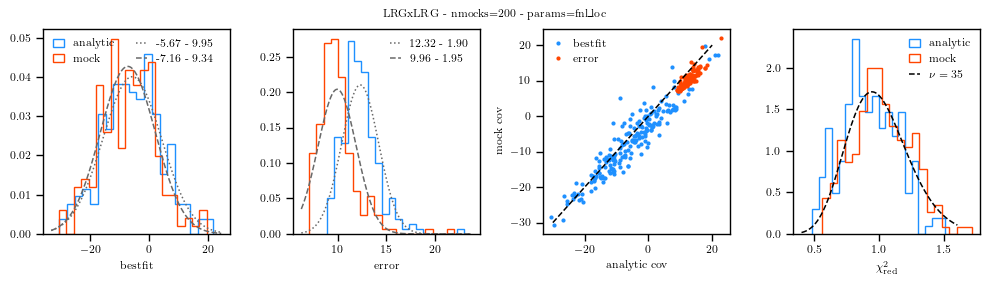

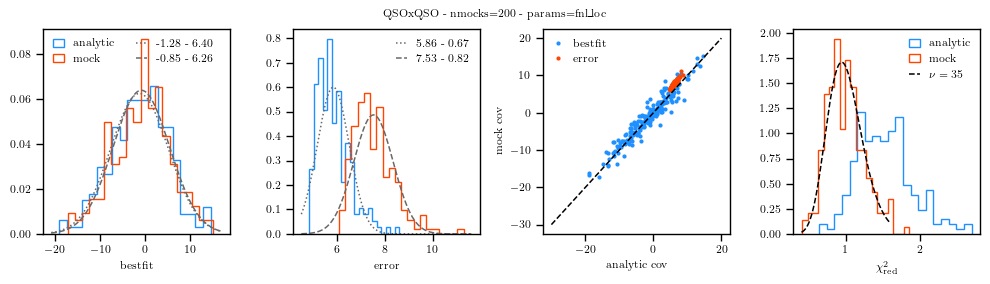

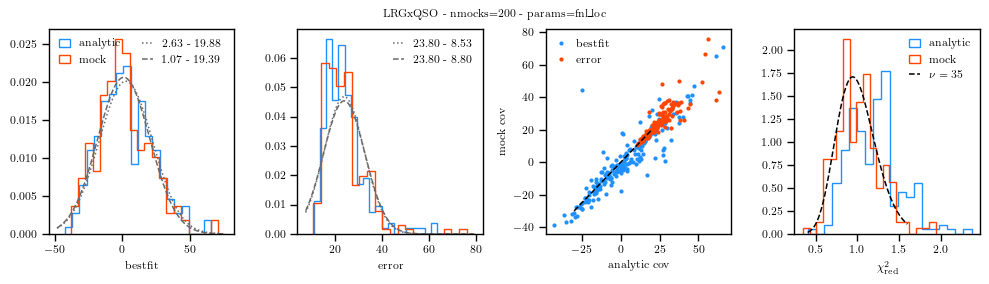

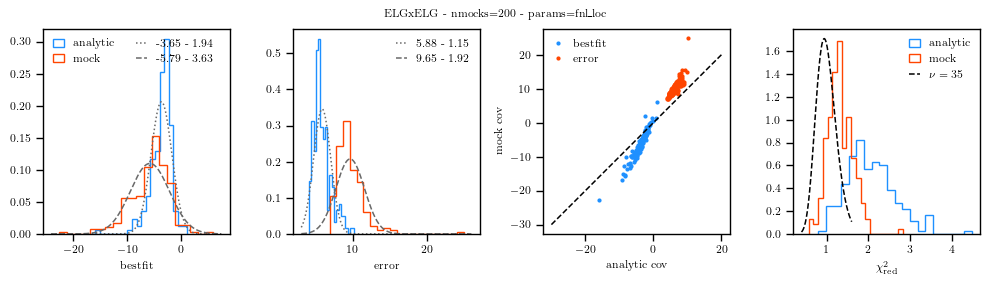

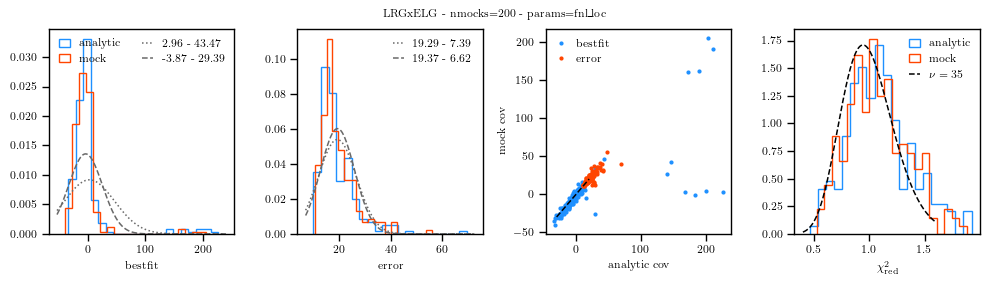

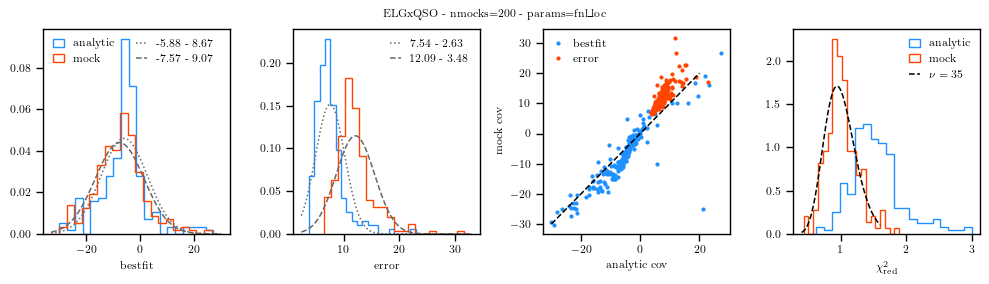

In [6]:
from scipy.stats import norm, chi2

if True:
    pdf_path = Path('fig/fit_individual_mocks.pdf')

    only_fnl = True

    tracers = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'ELGxELG', 'LRGxELG', 'ELGxQSO']

    with PdfPages(pdf_path) as pdf:
        for tracer in tracers:
            prof = profiles[tracer]
            for j in range(1 if only_fnl else 4):
                plt.figure(figsize=(10, 3))
                plt.subplot(141)
                plt.hist([float(prof['ana_cov'][i][j][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label='analytic')
                plt.hist([float(prof['mock_cov'][i][j][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label='mock')
                xmin, xmax = plt.xlim()
                x = np.linspace(xmin, xmax, 1000)
                mu, std = norm.fit([float(prof['ana_cov'][i][j][2]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls=':', label=f'{mu:2.2f} - {std:2.2f}')
                mu, std = norm.fit([float(prof['mock_cov'][i][j][2]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls='--', label=f'{mu:2.2f} - {std:2.2f}')
                plt.legend(loc='upper left', ncol=2)
                plt.xlabel('bestfit')
                #if j == 0: plt.axvline(0, ls='--', c='k', alpha=0.5, zorder=0)
                plt.subplot(142)
                plt.hist([float(prof['ana_cov'][i][j][3]) for i in range(nmocks)], bins=20, density=True, histtype='step')
                plt.hist([float(prof['mock_cov'][i][j][3]) for i in range(nmocks)], bins=20, density=True, histtype='step')
                xmin, xmax = plt.xlim()
                x = np.linspace(xmin, xmax, 1000)
                mu, std = norm.fit([float(prof['ana_cov'][i][j][3]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls=':', label=f'{mu:2.2f} - {std:2.2f}')
                mu, std = norm.fit([float(prof['mock_cov'][i][j][3]) for i in range(nmocks)])
                plt.plot(x, norm.pdf(x, mu, std), c='dimgray', ls='--', label=f'{mu:2.2f} - {std:2.2f}')
                plt.legend()
                plt.xlabel('error')
                plt.subplot(143)
                plt.plot([float(prof['ana_cov'][i][j][2]) for i in range(nmocks)], [float(prof['mock_cov'][i][j][2]) for i in range(nmocks)], ls='', marker='.', label='bestfit')
                plt.plot([float(prof['ana_cov'][i][j][3]) for i in range(nmocks)], [float(prof['mock_cov'][i][j][3]) for i in range(nmocks)], ls='', marker='.', label='error')
                if j == 0: plt.plot([-30, 20], [-30, 20], ls='--', c='k')
                plt.xlabel('analytic cov')
                plt.ylabel('mock cov')
                plt.legend()
                plt.subplot(144)
                ndof = mocks[tracer][0].select(k=(kmin, 1)).size - 4
                plt.hist([-2*float(prof['ana_cov'][i][4][2]) / ndof for i in range(nmocks)], histtype='step', bins=20, density=True, label='analytic')
                from lsstypes.utils import get_percival2014_factor
                percival = get_percival2014_factor(len(mocks['LRGxLRG']), ndof+4, 4) # don't forget to remove th percival factor when quoting the chi2 
                plt.hist([-2*float(prof['mock_cov'][i][4][2]) * percival / ndof for i in range(nmocks)], histtype='step', bins=20, density=True, label='mock')
                x = np.linspace(0.4, 1.6, 500)
                plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='k')
                plt.legend()    
                plt.xlabel(r'$\chi^2_{\rm{red}}$')
                plt.suptitle(f"{tracer} - {nmocks=} - params={prof['ana_cov'][0][j][0]}", fontsize=8, y=0.93)
                plt.tight_layout()
                pdf.savefig(plt.gcf())
                plt.show()
        
        pdf_path.resolve()

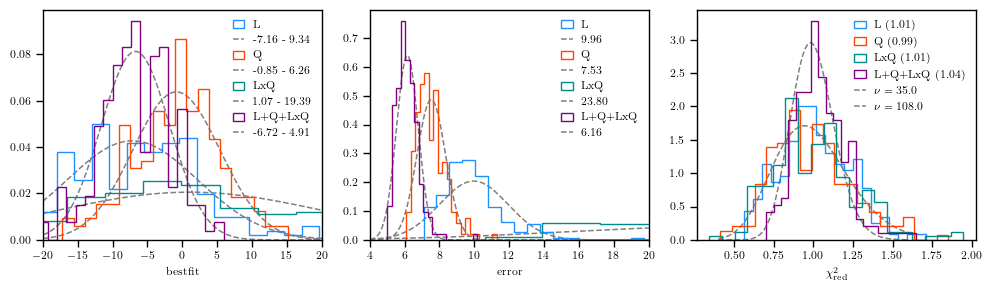

In [7]:
from scipy.stats import norm, chi2

tracers_to_plot = ['LRGxLRG', 'QSOxQSO', 'LRGxQSO', 'LRGxLRG-LRGxQSO-QSOxQSO']

labels = {'LRGxLRG': 'L', 'QSOxQSO': 'Q', 'LRGxQSO': 'LxQ', 'LRGxLRG-LRGxQSO-QSOxQSO': 'L+Q+LxQ'}

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.xlim(-20,20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][i][0][2]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('bestfit')

plt.subplot(132)
plt.xlim(4, 20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][i][0][3]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('error')

plt.subplot(133)
ndofs = []
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    idx_logpost = np.where(prof['mock_cov'][0][:,0] == 'logposterior')[0][0]
    nparams = float(np.sum(prof['mock_cov'][0][:,3] > ''))
    if "-" not in tracer:  
        nbins = mocks[tracer][0].select(k=(kmin, 1)).size    
    else:
        nbins = sum([mocks[tt][0].select(k=(kmin, 1)).size for tt in tracer.split("-")])
    ndof = nbins - nparams
    ndofs.append(ndof)

    from lsstypes.utils import get_percival2014_factor
    percival = get_percival2014_factor(len(mocks['LRGxLRG']), nbins, nparams)

    red_chi2 = [-2*float(prof['mock_cov'][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

    plt.hist(red_chi2, histtype='step', bins=20, density=True, label=labels[tracer] + f' ({np.mean(red_chi2):.2f})')

for ndof in np.unique(ndofs):
    x = np.linspace(0.4, 1.6, 500)
    plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='gray', zorder=0)

plt.legend()    
plt.xlabel(r'$\chi^2_{\rm{red}}$')
plt.tight_layout()
plt.savefig('fig/fit_individual_mocks_png.pdf')
plt.show()


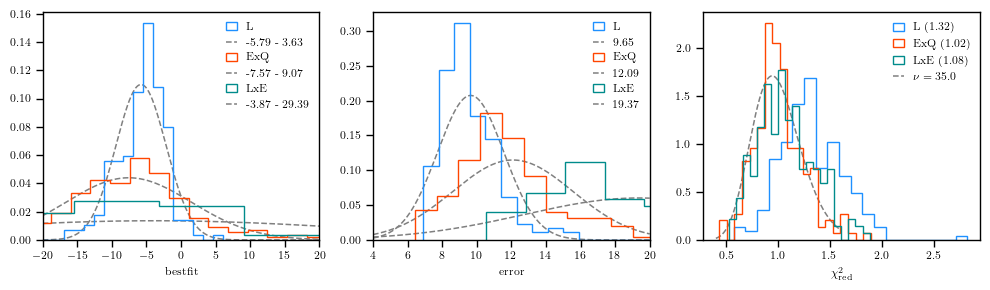

In [7]:
from scipy.stats import norm, chi2

tracers_to_plot = ['ELGxELG', 'ELGxQSO', 'LRGxELG']

labels = {'ELGxELG': 'L', 'ELGxQSO': 'ExQ', 'LRGxELG': 'LxE'}

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.xlim(-20,20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][i][0][2]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][i][0][2]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f} - {std:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('bestfit')

plt.subplot(132)
plt.xlim(4, 20)
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    plt.hist([float(prof['mock_cov'][i][0][3]) for i in range(nmocks)], histtype='step', bins=20, density=True, label=labels[tracer])
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 1000)
    mu, std = norm.fit([float(prof['mock_cov'][i][0][3]) for i in range(nmocks)])
    plt.plot(x, norm.pdf(x, mu, std), c='gray', ls='--', label=f'{mu:2.2f}', zorder=0)
plt.legend(loc='upper right', ncol=1)
plt.xlabel('error')

plt.subplot(133)
ndofs = []
for tracer in tracers_to_plot:
    prof = profiles[tracer]
    idx_logpost = np.where(prof['mock_cov'][0][:,0] == 'logposterior')[0][0]
    nparams = float(np.sum(prof['mock_cov'][0][:,3] > ''))
    if "-" not in tracer:  
        nbins = mocks[tracer][0].select(k=(kmin, 1)).size    
    else:
        nbins = sum([mocks[tt][0].select(k=(kmin, 1)).size for tt in tracer.split("-")])
    ndof = nbins - nparams
    ndofs.append(ndof)

    from lsstypes.utils import get_percival2014_factor
    percival = get_percival2014_factor(len(mocks['LRGxLRG']), nbins, nparams)

    red_chi2 = [-2*float(prof['mock_cov'][i][idx_logpost][2]) * percival / ndof for i in range(nmocks)]

    plt.hist(red_chi2, histtype='step', bins=20, density=True, label=labels[tracer] + f' ({np.mean(red_chi2):.2f})')

for ndof in np.unique(ndofs):
    x = np.linspace(0.4, 1.6, 500)
    plt.plot(x, chi2.pdf(x, df=ndof, scale=1/ndof), label=fr'$\nu={ndof}$', ls='--', c='gray', zorder=0)

plt.legend()    
plt.xlabel(r'$\chi^2_{\rm{red}}$')
plt.tight_layout()
#plt.savefig('fig/fit_individual_mocks_png.pdf')
plt.show()
